In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

In [2]:
import geopandas as gpd
from src.geodata import filter_county

In [3]:
print(Path.cwd())

d:\Wu\2026\Project Portfolio\002 Project\grocery_access\notebooks


In [4]:
data_dir = Path("../data/raw/tract_2024")
print(data_dir)
print(data_dir.exists())

..\data\raw\tract_2024
True


In [5]:
list(data_dir.iterdir())

[WindowsPath('../data/raw/tract_2024/cb_2024_16_tract_500k.cpg'),
 WindowsPath('../data/raw/tract_2024/cb_2024_16_tract_500k.dbf'),
 WindowsPath('../data/raw/tract_2024/cb_2024_16_tract_500k.prj'),
 WindowsPath('../data/raw/tract_2024/cb_2024_16_tract_500k.shp'),
 WindowsPath('../data/raw/tract_2024/cb_2024_16_tract_500k.shp.ea.iso.xml'),
 WindowsPath('../data/raw/tract_2024/cb_2024_16_tract_500k.shp.iso.xml'),
 WindowsPath('../data/raw/tract_2024/cb_2024_16_tract_500k.shx')]

In [6]:
shp_path = next(data_dir.glob("*.shp"))
gdf = gpd.read_file(shp_path)
gdf.head()

,STATEFP,COUNTYFP,TRACTCE,GEOIDFQ,GEOID,NAME,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,LSAD,ALAND,AWATER,geometry
0,16,017,950100,1400000US16017950100,16017950100,9501,Census Tract 9501,ID,Bonner County,Idaho,CT,1040606721,159680574,"POLYGON ((-116.50511 47.94953, -116.50481 47.9..."
1,16,059,970200,1400000US16059970200,16059970200,9702,Census Tract 9702,ID,Lemhi County,Idaho,CT,1230047586,1802039,"POLYGON ((-113.99543 45.41691, -113.9945 45.42..."
2,16,083,000300,1400000US16083000300,16083000300,3,Census Tract 3,ID,Twin Falls County,Idaho,CT,381182424,2847873,"POLYGON ((-114.95143 42.53916, -114.9495 42.54..."
3,16,039,960500,1400000US16039960500,16039960500,9605,Census Tract 9605,ID,Elmore County,Idaho,CT,25833164,92328,"POLYGON ((-115.89592 43.07025, -115.88581 43.0..."
4,16,001,010501,1400000US16001010501,16001010501,105.01,Census Tract 105.01,ID,Ada County,Idaho,CT,1022415884,5451232,"POLYGON ((-116.51362 43.38654, -116.51353 43.4..."


In [7]:
gdf.columns

Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOIDFQ', 'GEOID', 'NAME',
       'NAMELSAD', 'STUSPS', 'NAMELSADCO', 'STATE_NAME', 'LSAD', 'ALAND',
       'AWATER', 'geometry'],
      dtype='str')

In [8]:
gdf.shape

(456, 14)

In [9]:
gdf[['STATEFP', 'COUNTYFP','NAME']].head(10)

,STATEFP,COUNTYFP,NAME
0,16,017,9501
1,16,059,9702
2,16,083,3
3,16,039,9605
4,16,001,105.01
5,16,053,9704
6,16,065,9503.01
7,16,045,9601
8,16,005,16.01
9,16,023,9701


In [ ]:
kootenai = filter_county(gdf, state_fp="16", county_fp="055")

<Axes: >

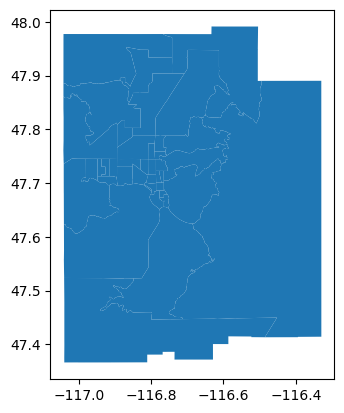

In [11]:
kootenai.plot()

In [12]:
kootenai.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

In [17]:
# Check and project coordinate system
kootenai = kootenai.to_crs(epsg=26911)  # NAD83 / UTM Zone11N
kootenai.crs

<Projected CRS: EPSG:26911>
Name: NAD83 / UTM zone 11N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: North America - between 120°W and 114°W - onshore and offshore. Canada - Alberta; British Columbia; Northwest Territories; Nunavut. United States (USA) - California; Idaho; Nevada, Oregon; Washington.
- bounds: (-120.0, 30.88, -114.0, 83.5)
Coordinate Operation:
- name: UTM zone 11N
- method: Transverse Mercator
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [ ]:
# geogrpahic extends (minx, miny, maxx, maxy)
kootenai.total_bounds    

array([ 496803.30170676, 5245841.54247203,  550587.04556282,
       5315461.67551346])

In [20]:
print(len(kootenai))

39


In [23]:
kootenai.to_file("../data/processed/kootenai_tracts.gpkg",
    driver="GPKG")